In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")
print(f"Versión de Keras: {tf.keras.__version__}")
!python --version
print("*"*100)
!nvidia-smi

Versión de TensorFlow: 2.20.0
Versión de Keras: 3.13.2
Python 3.13.15
****************************************************************************************************
Fri Aug 28 20:31:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       0MiB /  153

In [ ]:
print("Gpu disponible: ", tf.config.list_physical_devices('GPU'))

Gpu disponible:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
test_images.shape

(10000, 28, 28)

In [ ]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

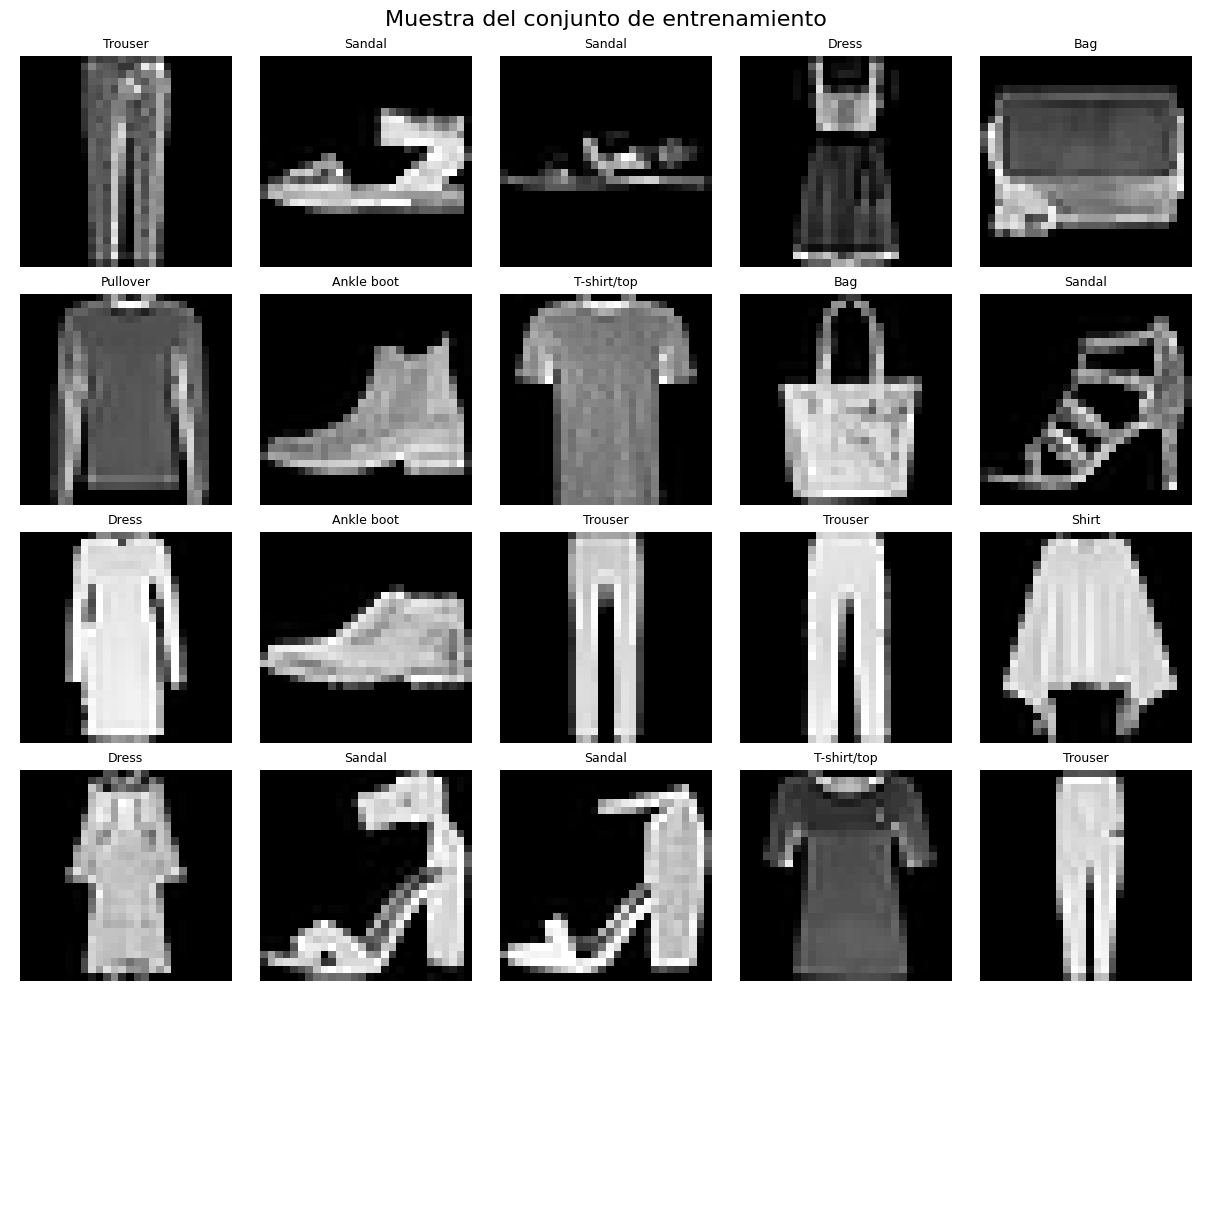

In [ ]:
# Mostrar una muestra representativa de las imágenes de entrenamiento
rng = np.random.default_rng(42)
num_images = min(20, len(train_images))
selected_indices = rng.choice(len(train_images), size=num_images, replace=False)
grid_size = int(np.ceil(np.sqrt(num_images)))

fig, axes = plt.subplots(
    grid_size,
    grid_size,
    figsize=(12, 12),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for axis, image_index in zip(axes, selected_indices):
    axis.imshow(train_images[image_index], cmap="gray")
    axis.set_title(class_names[train_labels[image_index]], fontsize=9)
    axis.axis("off")

for axis in axes[num_images:]:
    axis.axis("off")

fig.suptitle("Muestra del conjunto de entrenamiento", fontsize=16)
plt.show()

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
model = models.Sequential(name="fashion_mnist_model")

model.add(layers.InputLayer(shape=(28, 28)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [ ]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8004 - loss: 0.5764
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8561 - loss: 0.3989
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8703 - loss: 0.3612
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8770 - loss: 0.3369
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8839 - loss: 0.3193
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8880 - loss: 0.3036
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8910 - loss: 0.2952
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8949 - loss: 0.2841
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8985 - loss: 0.2745
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8999 - loss: 0.2680


In [ ]:
# Cargar Google Drive en el entorno de ejecución de Google Colab
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

carpeta_drive = Path('/content/drive/MyDrive/Ciencia de datos')
print(f'Carpeta disponible: {carpeta_drive}')
print(f'Existe: {carpeta_drive.exists()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpeta disponible: /content/drive/MyDrive/Ciencia de datos
Existe: True


In [ ]:
# Guardar el modelo entrenado en Google Drive
ruta_modelo = carpeta_drive / "fashion_mnist_model.keras"
model.save(ruta_modelo)
print(f"Modelo guardado en: {ruta_modelo}")

Modelo guardado en: /content/drive/MyDrive/Ciencia de datos/fashion_mnist_model.keras


In [ ]:
!pwd

/content


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print('\n Test accuracy:', test_acc)

313/313 - 3s - 8ms/step - accuracy: 0.8743 - loss: 0.3560

 Test accuracy: 0.8743000030517578


In [ ]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
predictions[0]

array([2.8849032e-09, 1.2432990e-06, 9.3401432e-11, 1.9166258e-07,
       1.6332238e-09, 3.7955565e-04, 6.5561290e-10, 5.6967409e-03,
       5.3015892e-06, 9.9391687e-01], dtype=float32)

In [ ]:
np.argmax(predictions[0])

np.int64(9)

In [ ]:
posicion = test_labels[0]

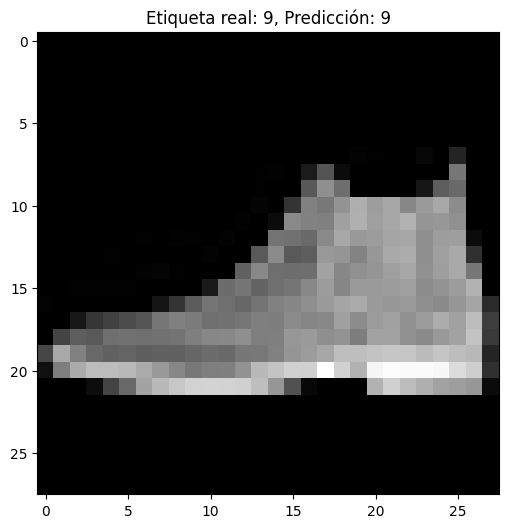

In [ ]:
# Mostrar la imagen de prueba junto con la predicción del modelo
plt.figure(figsize=(6, 6))
plt.imshow(test_images[0], cmap='gray')
plt.title(f"Etiqueta real: {posicion}, Predicción: {np.argmax(predictions[0])}")
plt.show()

In [ ]:
print(class_names[posicion])

Ankle boot
